In [25]:
from  langchain_community.document_loaders import PyPDFLoader
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings,OpenAI,ChatOpenAI
os.environ['OPENAI_API_KEY']=os.getenv("OPENAI_API_KEY")
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

In [35]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [26]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['OPENAI_API_KEY']=os.getenv("OPENAI_API_KEY")
from  langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

In [27]:
from typing import TypedDict

from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, END

In [28]:
class AgentState(TypedDict):
    question: str
    topic: str
    documents: list
    answer: str

In [29]:
def build_vector_db(folder):

    loader = PyPDFLoader(folder)
    docs = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=100
    )

    chunks = splitter.split_documents(docs)

    embeddings = OpenAIEmbeddings()

    vectordb = Chroma.from_documents(
        chunks,
        embeddings,
        persist_directory=f"db_{folder}"
    )

    return vectordb


In [30]:
chess_db = build_vector_db(r"books\chess_guide.pdf")

In [32]:
chess_db = build_vector_db(r"books/chess_guide.pdf")
medical_db = build_vector_db(r"books/medical_basics.pdf")
stock_db = build_vector_db(r"books/stock_market_basics.pdf")
cricket_db = build_vector_db(r"books/cricket_guide.pdf")

In [33]:
# define router 
def route_question(state: AgentState):

    question = state["question"].lower()

    if "chess" in question:
        topic = "chess"

    elif "medicine" in question or "disease" in question:
        topic = "medical"

    elif "stock" in question or "trading" in question:
        topic = "stock"

    elif "cricket" in question:
        topic = "cricket"

    else:
        topic = "chess"

    return {**state, "topic": topic}

In [34]:
def retrieve_docs(state: AgentState):

    topic = state["topic"]
    question = state["question"]

    if topic == "chess":
        db = chess_db

    elif topic == "medical":
        db = medical_db

    elif topic == "stock":
        db = stock_db

    else:
        db = cricket_db

    docs = db.similarity_search(question, k=4)

    return {**state, "documents": docs}


In [ ]:
def generate_answer(state: AgentState):

    docs = state["documents"]
    question = state["question"]

    context = "\n\n".join([doc.page_content for doc in docs])

    prompt = f"""
    Answer the question using the context below.

    Context:
    {context}

    Question:
    {question}
    """

    response = llm.invoke(prompt)

    return {**state, "answer": response.content}

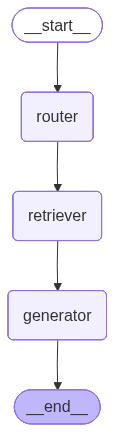

In [41]:

# -----------------------------
# BUILD LANGGRAPH
# -----------------------------

builder = StateGraph(AgentState)

builder.add_node("router", route_question)
builder.add_node("retriever", retrieve_docs)
builder.add_node("generator", generate_answer)

builder.set_entry_point("router")

builder.add_edge("router", "retriever")
builder.add_edge("retriever", "generator")
builder.add_edge("generator", END)

graph = builder.compile()
graph


In [39]:

question = "Explain basic in chess"

result = graph.invoke({
    "question": question
})

print(result["answer"])

In chess, the basics involve understanding the game's structure, objectives, and piece movements. Chess is played on an 8x8 board with 64 squares, with each player starting with 16 pieces: 1 King, 1 Queen, 2 Rooks, 2 Knights, 2 Bishops, and 8 Pawns. The primary objective is to checkmate the opponent's king, meaning the king is under attack and cannot escape from that attack.

Basic piece movements include:

- **King**: Moves one square in any direction.
- **Queen**: Moves any number of squares in any direction.
- **Rook**: Moves any number of squares horizontally or vertically.

Additionally, chess can be divided into three main phases:

1. **Opening**: The initial phase where players develop their pieces and aim to control the center of the board.
2. **Middlegame**: Players create tactics, attack opposing pieces, and seek to improve their positions.
3. **Endgame**: Characterized by fewer pieces on the board, where the focus shifts to promoting pawns and achieving checkmate.

Overall, 

In [42]:

question = "investment statergy"

result = graph.invoke({
    "question": question
})

print(result["answer"])

The provided context focuses on chess, discussing the movements of various pieces, basic strategies, and the different phases of the game. It does not contain information related to investment strategies. If you are looking for investment strategies, I recommend exploring topics like diversification, asset allocation, risk management, and setting financial goals. If you have a specific aspect of investment strategies in mind, please let me know!
